First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol  

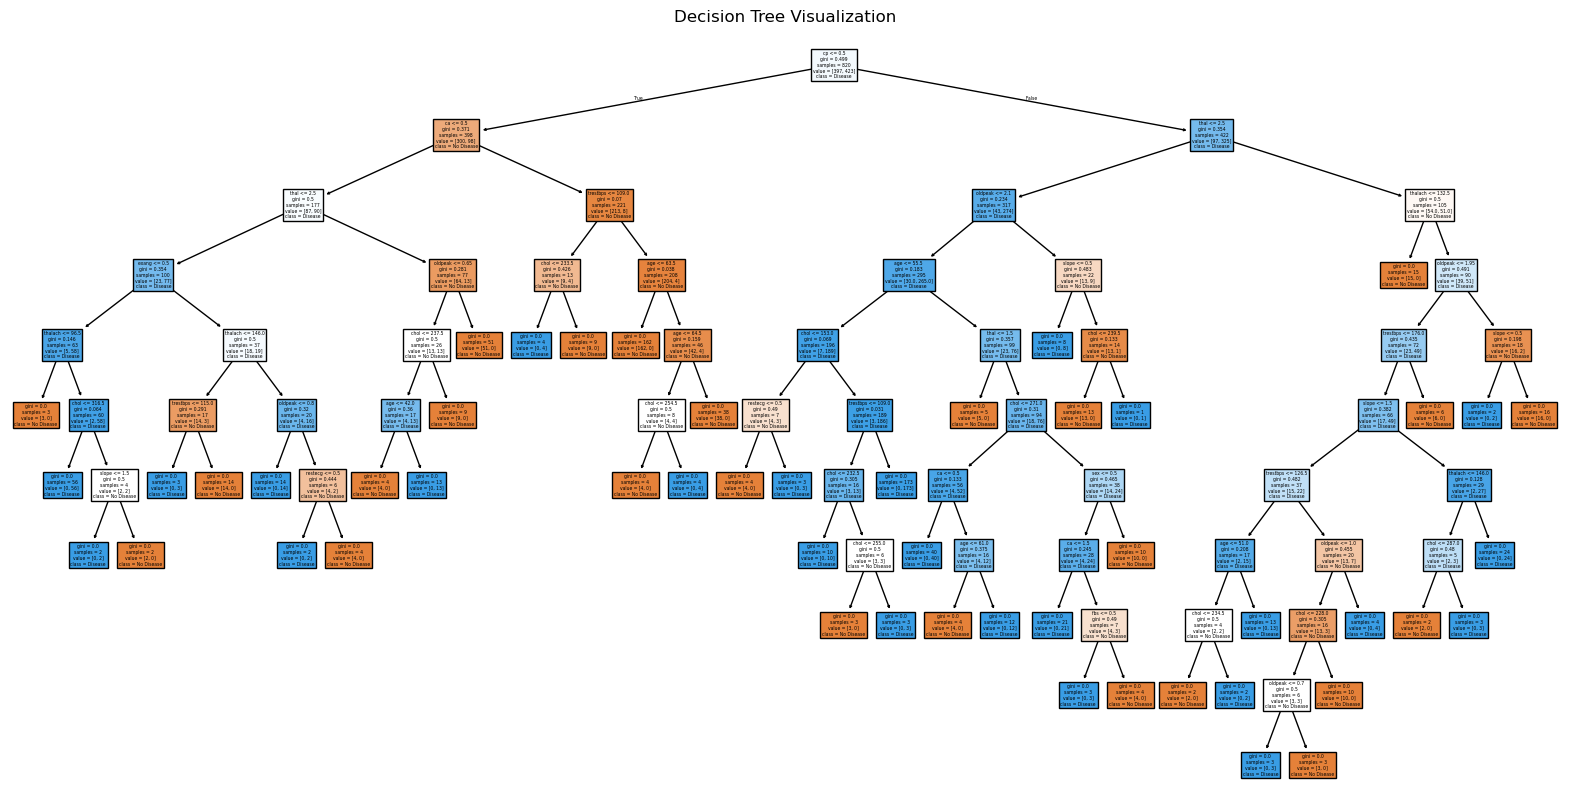


===== Decision Tree with max_depth=3 =====
Accuracy after controlling depth: 0.7804878048780488

===== Random Forest Classifier =====
Random Forest Accuracy: 0.9853658536585366

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


Feature Importance:
     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


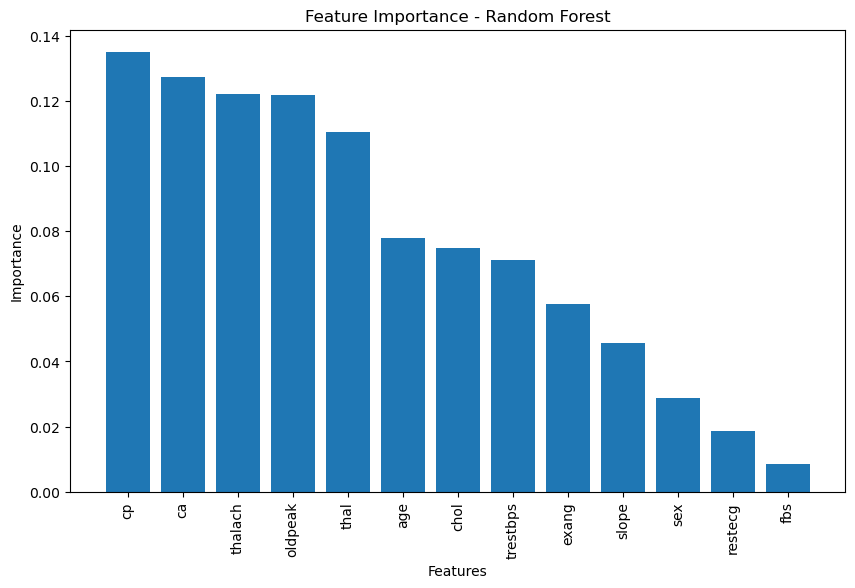


Cross Validation Scores:
[1.         1.         1.         1.         0.98536585]
Average CV Accuracy: 0.9970731707317073

===== Model Comparison =====
Decision Tree Accuracy : 0.9853658536585366
Depth Controlled Tree  : 0.7804878048780488
Random Forest Accuracy : 0.9853658536585366
Cross Validation Mean  : 0.9970731707317073


In [3]:
# ==========================================
# Task 5: Decision Trees and Random Forests
# Heart Disease Dataset
# ==========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load Dataset

df = pd.read_csv(r"C:\Users\sirik\OneDrive\Desktop\AIML TASKS\heart.csv")
# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 3: Separate Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Step 4: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Decision Tree Classifier
# ==========================================

print("\n===== Decision Tree Classifier =====")

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediction
y_pred_dt = dt.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# ==========================================
# Visualize Decision Tree
# ==========================================

plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

# ==========================================
# Overfitting Control using max_depth
# ==========================================

print("\n===== Decision Tree with max_depth=3 =====")

dt_depth = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_depth.fit(X_train, y_train)

y_pred_depth = dt_depth.predict(X_test)

depth_accuracy = accuracy_score(y_test, y_pred_depth)

print("Accuracy after controlling depth:", depth_accuracy)

# ==========================================
# Random Forest Classifier
# ==========================================

print("\n===== Random Forest Classifier =====")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))
plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# ==========================================
# Cross Validation
# ==========================================

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("\nCross Validation Scores:")
print(cv_scores)

print("Average CV Accuracy:",
      cv_scores.mean())

# ==========================================
# Final Comparison
# ==========================================

print("\n===== Model Comparison =====")
print("Decision Tree Accuracy :", dt_accuracy)
print("Depth Controlled Tree  :", depth_accuracy)
print("Random Forest Accuracy :", rf_accuracy)
print("Cross Validation Mean  :", cv_scores.mean())